### Convolutional Neural Network (CNN) for Image Classification

This notebook will guide you through designing and training a Convolutional Neural Network (CNN) for image classification using the MNIST dataset.

In [5]:
# 1. Import necessary libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


### Load and Preprocess the MNIST Dataset

In [6]:
# 2. Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print(f"Training images shape: {train_images.shape}")
print(f"Testing images shape: {test_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Testing labels shape: {test_labels.shape}")

Training images shape: (60000, 28, 28)
Testing images shape: (10000, 28, 28)
Training labels shape: (60000,)
Testing labels shape: (10000,)


In [7]:
# 3. Preprocess the data

# Normalize pixel values to [0, 1]
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Reshape images to add a channel dimension (for grayscale, it's 1)
# CNNs expect input in the format (batch, height, width, channels)
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

# Convert labels to one-hot encoding
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

print(f"Reshaped training images shape: {train_images.shape}")
print(f"Reshaped testing images shape: {test_images.shape}")
print(f"One-hot encoded training labels shape: {train_labels.shape}")
print(f"One-hot encoded testing labels shape: {test_labels.shape}")

Reshaped training images shape: (60000, 28, 28, 1)
Reshaped testing images shape: (10000, 28, 28, 1)
One-hot encoded training labels shape: (60000, 10)
One-hot encoded testing labels shape: (10000, 10)


### Visualize Sample Data

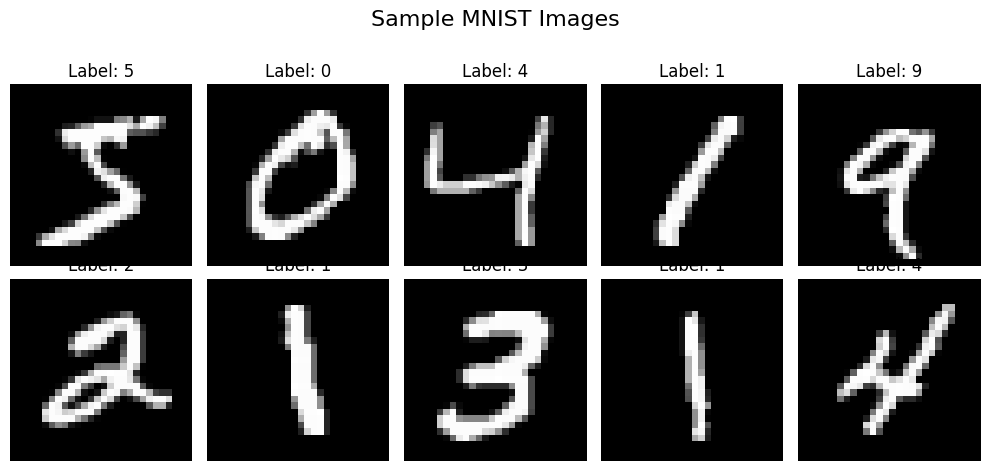

In [4]:
# 4. Display a few sample images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(train_labels[i])}")
    plt.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Build the CNN Model

In [8]:
# 5. Build the CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax') # 10 classes for MNIST
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

In [12]:
# 7. Train the model
history = model.fit(train_images, train_labels, epochs=10, batch_size=32, validation_data=(test_images, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9991 - loss: 0.0025 - val_accuracy: 0.9910 - val_loss: 0.0586
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9990 - loss: 0.0032 - val_accuracy: 0.9926 - val_loss: 0.0534
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 27ms/step - accuracy: 0.9994 - loss: 0.0022 - val_accuracy: 0.9905 - val_loss: 0.0596
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 28ms/step - accuracy: 0.9992 - loss: 0.0029 - val_accuracy: 0.9920 - val_loss: 0.0613
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.9989 - loss: 0.0039 - val_accuracy: 0.9898 - val_loss: 0.0789
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9993 - loss: 0.0024 - val_accuracy: 0.9916 - val_loss: 0.0568
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9992 - loss: 0.0026 - val_accuracy: 0.9902 - val_loss: 0.0782
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 27ms/step - accuracy: 0.9995 -

### Evaluate the Model

In [13]:
# 8. Evaluate the model
loss, accuracy = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.0533
Test Accuracy: 0.9916


### Train the Model

In [10]:
# 7. Train the model
history = model.fit(train_images, train_labels, epochs=10, batch_size=32, validation_data=(test_images, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9622 - loss: 0.1236 - val_accuracy: 0.9868 - val_loss: 0.0434
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9872 - loss: 0.0413 - val_accuracy: 0.9898 - val_loss: 0.0322
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9914 - loss: 0.0281 - val_accuracy: 0.9906 - val_loss: 0.0275
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9937 - loss: 0.0209 - val_accuracy: 0.9881 - val_loss: 0.0388
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9951 - loss: 0.0148 - val_accuracy: 0.9910 - val_loss: 0.0295
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9962 - loss: 0.0113 - val_accuracy: 0.9905 - val_loss: 0.0330
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9968 - loss: 0.0095 - val_accuracy: 0.9910 - val_loss: 0.0356
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9974 -

### Evaluate the Model

In [14]:
# 8. Evaluate the model
loss, accuracy = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.0533
Test Accuracy: 0.9916


### Compile the Model

In [15]:
# 6. Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])